In [4]:
#导入所需要的模块与包
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# 设置数据路径
TRAINING_DIR = "/Users/siyu/Study_2025-2026-01/MLcode/traffic/train/"
VALIDATION_DIR = "/Users/siyu/Study_2025-2026-01/MLcode/traffic/validation/"
TEST_DIR = "/Users/siyu/Study_2025-2026-01/MLcode/traffic/test/"

In [2]:
#对训练集做数据归一化及增强处理
training_datagen=tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,    #归一化
    rotation_range=40,    #旋转
    width_shift_range=0.2,    #水平平移
    height_shift_range=0.2,    #垂直平移
    shear_range=0.2,    #剪切
    zoom_range=0.2,    #缩放
    horizontal_flip=True,    #水平翻转
    fill_mode='nearest')
train_generator=training_datagen.flow_from_directory(TRAINING_DIR,
target_size=(150,150),class_mode='categorical')

#对验证集做数据归一化处理
validation_datagen=tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255)    #归一化
validation_generator=validation_datagen.flow_from_directory(VALIDATION_DIR,target_size=(150,150),class_mode='categorical')

Found 4200 images belonging to 5 classes.
Found 600 images belonging to 5 classes.


数据集大小为：4200


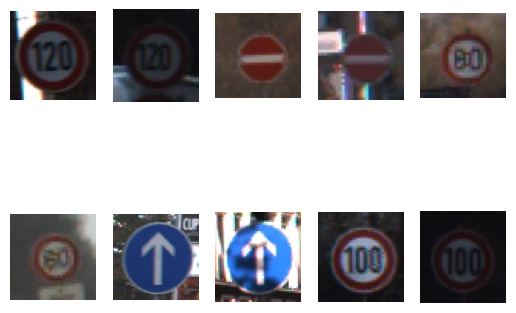

In [5]:
#定义显示图像函数
def display_image(data_dir):
    x_dir=[]
    x_filename=[]
    x_len=0
    #显示数据集大小
    for i in range(5):
        x_dir.append(os.path.join(data_dir,str(i)))
        x_filename.append(os.listdir(x_dir[i]))
        x_len=x_len+len(x_filename[i])
    print("数据集大小为："+str(x_len))
    #随机抽取图像存入 image 列表
    image=[]
    for i in range(5):
        for j in range(2):
            t=np.random.randint(0,len(x_filename[i]))
            image.append(x_dir[i]+'/'+x_filename[i][t])
    #显示 image 列表中的图像
    i=1
    for img_path in image:
        plt.subplot(2, 5, i)
        img=mpimg.imread(img_path)
        plt.imshow(img)
        plt.axis('Off')
        i=i+1
    plt.show()

display_image(TRAINING_DIR) #调用函数显示训练集图像

In [6]:
# CNN
model=tf.keras.models.Sequential([

tf.keras.layers.Conv2D(64,(3,3),activation='relu',input_shape=(150,150,3)),
tf.keras.layers.MaxPooling2D(2,2),
tf.keras.layers.Dropout(0.3),

tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
tf.keras.layers.MaxPooling2D(2,2),
tf.keras.layers.Dropout(0.3),

tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
tf.keras.layers.MaxPooling2D(2,2),
tf.keras.layers.Dropout(0.3),

tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
tf.keras.layers.MaxPooling2D(2,2),
tf.keras.layers.Dropout(0.3),

tf.keras.layers.Flatten(),
tf.keras.layers.Dropout(0.5),
# 全连接层
tf.keras.layers.Dense(512,activation='relu'),
tf.keras.layers.Dropout(0.5),
# 输出层
tf.keras.layers.Dense(5,activation='softmax')
])
model.summary()

/opt/anaconda3/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-12-11 13:39:20.569936: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-12-11 13:39:20.570145: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-12-11 13:39:20.570165: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-12-11 13:39:20.570422: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-12-11 13:39:20.570447: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Creat

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,474,501 (13.25 MB)

 Trainable params: 3,474,501 (13.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.5514 - loss: 0.9975 - val_accuracy: 0.5900 - val_loss: 1.1154
Epoch 2/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.6290 - loss: 0.8101 - val_accuracy: 0.7933 - val_loss: 0.6024
Epoch 3/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.6560 - loss: 0.7271 - val_accuracy: 0.6733 - val_loss: 0.6269
Epoch 4/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.6812 - loss: 0.6824 - val_accuracy: 0.6550 - val_loss: 0.6235
Epoch 5/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.6960 - loss: 0.6473 - val_accuracy: 0.6983 - val_loss: 0.6123
Epoch 6/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 78ms/step - accuracy: 0.6974 - loss: 0.6359 - val_accuracy: 0.7117 - val_loss: 0.6266
Epoch 7/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 77ms/step - accuracy: 0.7119 - loss: 0.6218 - val_accuracy: 0.7550 - val_loss: 0.6167
Epoch 8/10
132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 76ms/step - accuracy: 0.7198 - loss: 0.6061 -

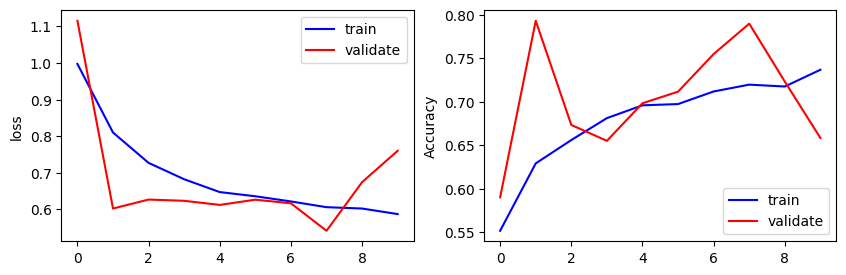

In [8]:
#编译网络模型
model.compile(loss='categorical_crossentropy',optimizer='rmsprop',metrics=['accuracy'])
#训练网络模型
history= model.fit(train_generator, epochs=10, validation_data =validation_generator,verbose=1)
model.save("traffic.h5")

#读取history的history属性
loss=history.history['loss']    #训练集损失函数值
acc=history.history['accuracy']    #训练集准确率
val_loss=history.history['val_loss']    #验证集损失函数值
val_acc=history.history['val_accuracy']    #验证集准确率
#创建面布并设置面布的大小
plt.figure(figsize=(10,3))
#在子图1中绘制损失函数值的折线图
plt.subplot(121)
plt.plot(loss,color='b',label='train')
plt.plot(val_loss,color='r',label='validate')
plt.ylabel('loss')
plt.legend()
#在子图2中绘制准确率的折线图
plt.subplot(122)
plt.plot(acc,color='b',label='train')
plt.plot(val_acc,color='r',label='validate')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


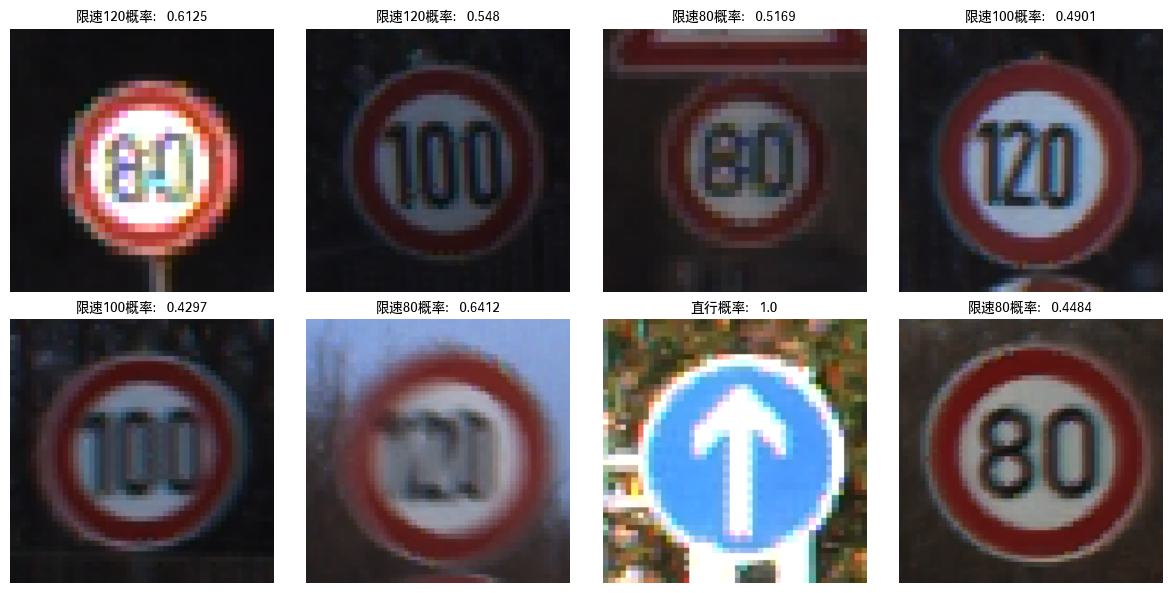

In [11]:
#定义读取测试集图像函数
def read_image_files(path,start,finish,image_size=(150,150)):
    test_files=os.listdir(path)
    test_images=[]
    #读取测试图像
    for fn in test_files[start:finish]:
        img_filename=os.path.join(path, fn)
        img=tf.keras.preprocessing.image.load_img(img_filename, target_size=image_size)
        img_array=tf.keras.preprocessing.image.img_to_array(img)
        test_images.append(img_array)
    test_data=np.array(test_images) #测试图像预处理
    test_data/=255.0
    return test_data

#定义预测函数
def test_image_predict(path,start,finish,image_size=(150,150)):
    #读取测试图像并预处理
    test_data=read_image_files(path,start,finish,image_size)
    #执行预测
    preds=model.predict(test_data)
    #显示图像及预测结果
    plt.rcParams['font.sans-serif']=['Hei']
    plt.figure(figsize=(12,6))
    for i in range(0,finish-start):
        plt.subplot(2,4,i+1)
        if np.argmax(preds[i])==0:
            label="限速120概率："+str(round(preds[i][0], 4))
        elif np.argmax(preds[i])==1:
            label="禁行概率："+str(round(preds[i][1], 4))
        elif np.argmax(preds[i])==2:
            label="限速80概率："+str(round(preds[i][2], 4))
        elif np.argmax(preds[i])==3:
            label="直行概率："+str(round(preds[i][3], 4))
        else:
            label="限速100概率："+str(round(preds[i][4], 4))
        plt.title(label, fontsize=10)
        plt.imshow(test_data[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

#读取测试数据并预测
test_image_predict(TEST_DIR,0,8)